# Neuron optimization

In [1]:
import jax
import jax.numpy as jnp
import snnax
import snnax.snn as snn

from eleanor.models import FeLIF

In [2]:
model = snn.Sequential(
    FeLIF(),
)
model

Sequential(
  graph_structure=GraphStructure(
    num_layers=1,
    input_layer_ids=((0,),),
    input_connectivity=((),)
  ),
  layers=[
    FeLIF(
      init_fn=<function <lambda>>,
      shape=None,
      A=25.0,
      E_a=0.00127,
      P_s=0.22,
      tau_0=1e-13,
      I_0=0.0001,
      V_t=0.32,
      C_tot=0.5728138392084845,
      alpha=1.3,
      soft_E=5e-06,
      I_dsc=10.0,
      V_thr=2.5,
      dt=0.001,
      cap_divider=0.00011097099621689785,
      depol_divider=0.000522215199039698,
      spike_fn=<function heaviside_with_superspike_surrogate>
    )
  ],
  forward_fn=<function default_forward_fn>,
  loop_fn=<wrapped function scan>
)

In [3]:
state = model.init_state((1,), jax.random.key(0))
state

[[Array([0.], dtype=float32),
  Array([-0.22], dtype=float32),
  Array([0.], dtype=float32)]]

In [4]:
input_ = 1e-1 * jnp.concatenate([jnp.ones((50, 1)), jnp.zeros((50, 1))])
states, outs = model(state, input_, key=jax.random.key(0))

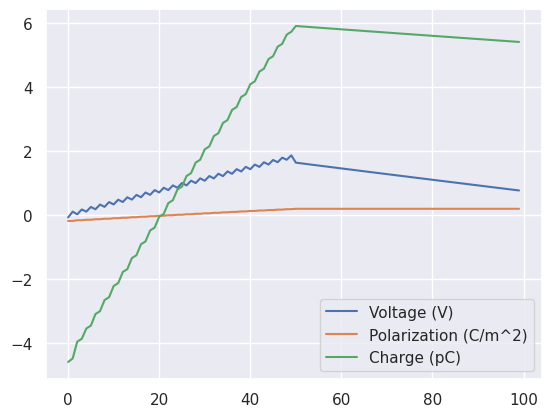

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

plt.plot(outs[0][1], label="Voltage (V)")
plt.plot(outs[0][2], label="Polarization (C/m^2)")
plt.plot(
    outs[0][1] * model.layers[0].C_tot + outs[0][2] * model.layers[0].A,
    label="Charge (pC)",
)
plt.legend()
plt.show()

In [6]:
import matplotlib.pyplot as plt
import optax
from tqdm import trange
from eleanor.models import FeLIF
import equinox as eqx
import jax.numpy as jnp
import jax
import snnax
import snnax.snn as snn

In [7]:
key = jax.random.key(0)

linearLayer = eqx.nn.Linear(1, 1, use_bias=False, key=key)
new_weight = jnp.asarray([[0.3]])
linearLayer = eqx.tree_at(lambda x: x.weight, linearLayer, new_weight)
model = snn.Sequential(
    linearLayer,
    FeLIF(
        dt=1e-3,
        A=25e-12,
        I_dsc=3.2532312693054174e-11,
        V_thr=1.698682296181096,
        P_s=0.13321217250476625,
        spike_fn=snnax.functional.surrogate.superspike_surrogate(beta=10.0),
        paramsScale=1e12,
    ),
)
init_state = model.init_state((1,), jax.random.key(0))
_, outs = model(init_state, jnp.zeros((10, 1)), jax.random.key(0))

In [8]:
@eqx.filter_jit
def predict(model, input_):
    init_state = model.init_state((1,), jax.random.key(0))
    _, outs = model(init_state, input_, jax.random.key(0))

    return outs[0][0], outs[0][1], outs[0][2]


@eqx.filter_jit
def loss(model, input_, target):
    preds, _, _ = predict(model, input_)
    preds = jnp.sum(preds, axis=0)  # Sum over time
    return jnp.mean((preds - target) ** 2)

In [9]:
opt = optax.sgd(learning_rate=5e-5)
opt_state = opt.init(model)

In [10]:
# Input every 5ms
input_ = jnp.array([[0], [0], [0], [0], [0], [0], [0], [0], [0], [1.0]] * 10)
target = jnp.array([2.0])

In [11]:
print("Optimizing")
loss_rec = []
param_rec = []
state = [model, opt_state]
nb_epochs = 15
for _ in trange(nb_epochs):
    grad_params, opt_state = state

    loss_val, grads = eqx.filter_value_and_grad(loss)(grad_params, input_, target)
    updates, opt_state = opt.update(grads, opt_state, grad_params)
    loss_rec.append(loss_val)

    new_param = eqx.apply_updates(grad_params, updates)
    state = [new_param, opt_state]
    param_rec.append(new_param.layers[0].weight[0, 0])
loss_rec = jnp.stack(loss_rec)
param_rec = jnp.stack(param_rec)

Optimizing


100%|██████████| 15/15 [00:07<00:00,  1.91it/s]


In [12]:
print("Predict")
preds_before, V_before, P_before = predict(model, input_)
preds, V, P = predict(state[0], input_)
print("Finish")

Predict
Finish


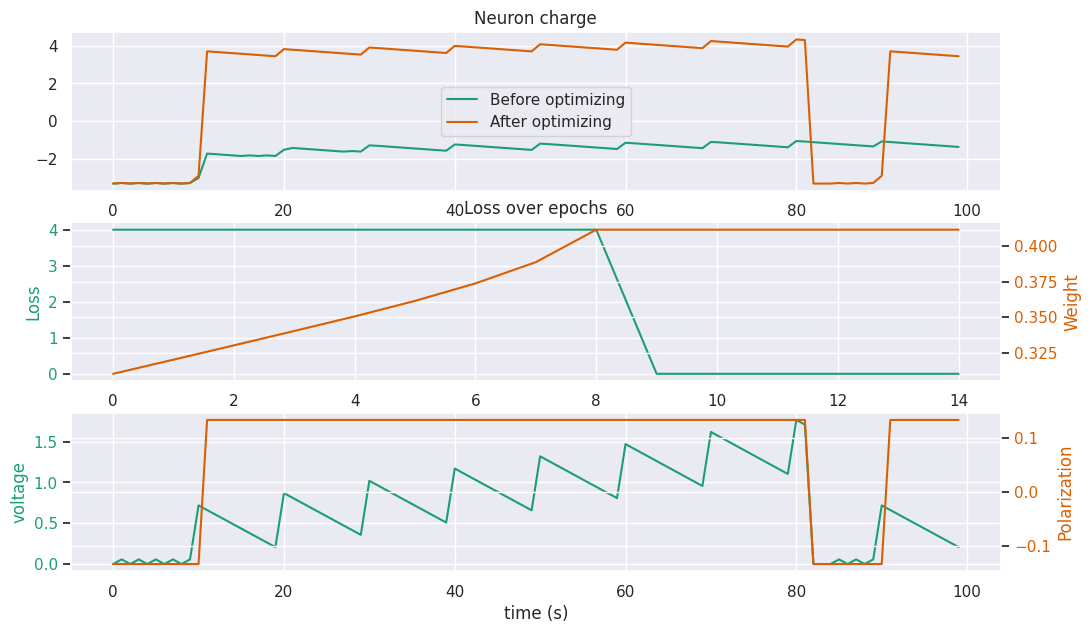

In [13]:
plt.figure(figsize=(12, 7))
plt.subplot(3, 1, 1)
plt.title("Neuron charge")
plt.plot(
    V_before * model.layers[1].C_tot + P_before * model.layers[1].A,
    c="#1b9e77",
    label="Before optimizing",
)
plt.plot(
    V * model.layers[1].C_tot + P * model.layers[1].A,
    c="#d95f02",
    label="After optimizing",
)
plt.legend()

ax1 = plt.subplot(3, 1, 2)
plt.title("Loss over epochs")

color = "#1b9e77"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color=color)
ax1.plot(loss_rec, color=color)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()

color = "#d95f02"
ax2.set_ylabel("Weight", color=color)
ax2.plot(param_rec, color=color)
ax2.tick_params(axis="y", labelcolor=color)

ax1 = plt.subplot(3, 1, 3)

color = "#1b9e77"
ax1.set_xlabel("time (s)")
ax1.set_ylabel("voltage", color=color)
ax1.plot(V, color=color)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()

color = "#d95f02"
ax2.set_ylabel("Polarization", color=color)
ax2.plot(P, color=color)
ax2.tick_params(axis="y", labelcolor=color)

plt.show()